In [244]:
import numpy as np
import gymnasium as gym
import importlib
import envs

import learners
import analysis
importlib.reload(analysis)
importlib.reload(learners)
from learners import *
from analysis import *

params = Params(
    model_name="Walkway",
    n_runs=5,
    n_episodes=20_000,
    save_skip=100,
    lr_decay=None,
    seed=123,
    
    N=256,
    alpha=0.2,
    gamma=0.5,
    epsilon=0.0,
    
    nA=None,
    nS=None,
    shape=None,
)
rng = np.random.default_rng(params.seed)
tau = (np.arange(params.N) + 0.5) / params.N
MoG = MixtureOfGaussians([1/2, 1/2], [-1, 3], [1, 1], rng)
env = gym.make(
    params.model_name,
    MoG=MoG,
    shape=(1,3),
)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

In [230]:
policy, V_pi = PolicyIteration(env, params.gamma)
explorer = EpsilonGreedy(params.epsilon, rng)

def get_exp_scheduler(alpha, n_ep_decay, min_val=0.005): return lambda t: max(alpha * 0.5**(t/n_ep_decay), min_val)
scheduler = get_exp_scheduler(params.alpha, 1250, min_val=0.00025)

table0 = QR(0, params, policy).train(env, explorer, scheduler)
table1 = QR(1, params, policy).train(env, explorer, scheduler)
qtable = Qlearner(params, policy).train(env, explorer, scheduler)

100%|██████████| 100000/100000 [01:14<00:00, 1339.19it/s, run=5, t=2e+4]


In [ ]:
returns = MonteCarlo(env, policy, params.gamma, total_episodes=1_000_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 1000000/1000000 [00:20<00:00, 48871.18it/s]


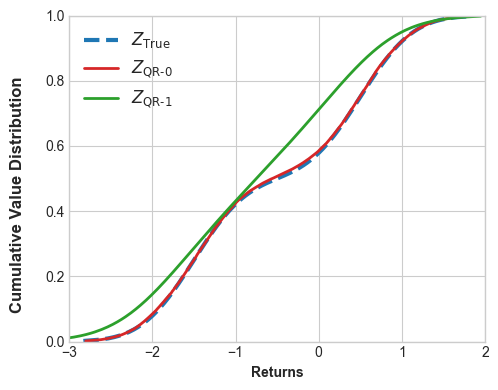

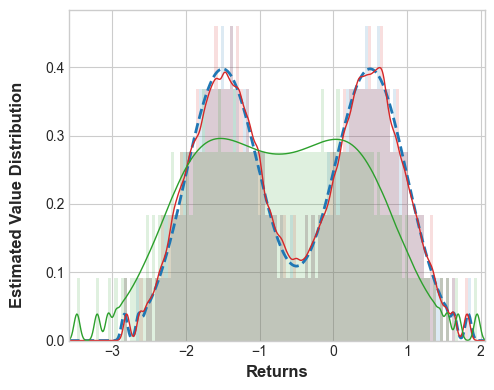

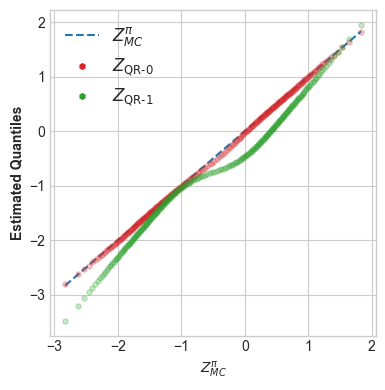

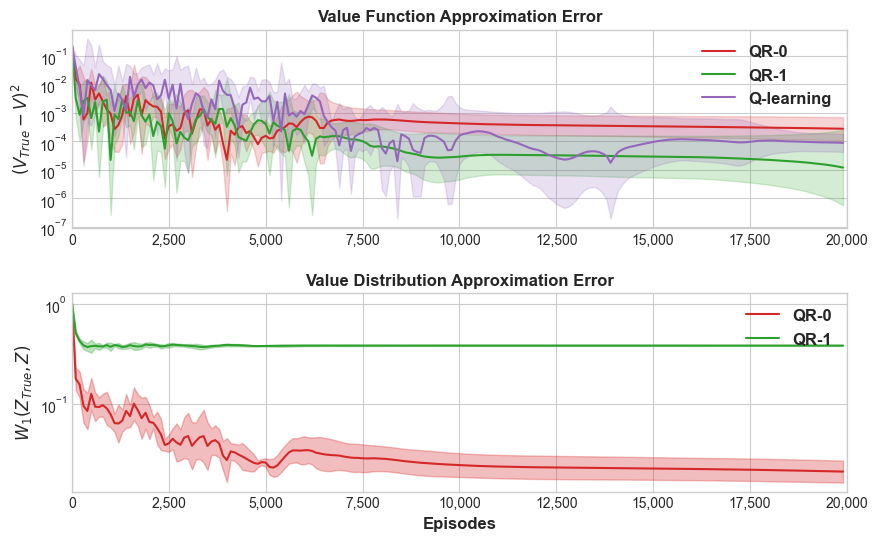

In [ ]:
def get_q(table): return table[:,:,s_init, policy[s_init].argmax()]
def get_best(table): return get_q(table)[:,-1].mean(0)

plot_objs = [
    (get_best(table0), r"$Z_{\text{QR-0}}$"),
    (get_best(table1), r"$Z_{\text{QR-1}}$"),
]
plot_qs = [
    (get_q(table0), "QR-0"),
    (get_q(table1), "QR-1"),
    (get_q(qtable), "Q-learning"),
]

tau_true = (env.unwrapped.rewards["step"] + params.gamma * MoG.ppf(tau))
save_to = "results/results/simplest_env"

LOW_BANDWIDTH = 0.04
bw = LOW_BANDWIDTH
plot_cdf(plot_objs, tau_true, tau, linewidths=(3,2), save_to=save_to, returns_name=r"$Z_{\text{True}}$")
plt.xlim(-3.0,2.0)

plot_pdf(plot_objs, tau_true, bandwidth=bw, show_hist=True, N=params.N//2, hist_alpha=0.15, save_to=save_to)
plot_qq(plot_objs, tau_true, save_to=save_to, alpha=0.25, markersize=4)
plot_metrics(plot_qs, tau_true, save_skip=params.save_skip, save_to=save_to, alphas=[0.2,0.3])